In [41]:
# ── Core Data Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization Libraries 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-Learn: Preprocessing 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Scikit-Learn: Model Selection 
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)

# ── Scikit-Learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ── Scikit-Learn: Evaluation Metrics 
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

# ── Imbalanced-Learn: SMOTE 
from imblearn.over_sampling import SMOTE



print("All libraries imported successfully!")

All libraries imported successfully!


In [42]:
df = pd.read_csv('smart_supplier_risk_dataset (1).csv')
df

,Supplier_ID,Average_Delivery_Delay_Days,On_Time_Delivery_%,Lifetime_Defect_Rate,Order_Fulfillment,Financial_Health_Score,Debt_Ratio,Contract_Years,Past_Defaults,Cost_Variation,Recent_3_Month_Defect_Rate,Target_Risk
0,S1,4.993428,79.916294,3.649643,80.460962,52.047596,0.415248,6,2,18.085225,3.898001,0
1,S2,3.723471,89.951772,4.210963,85.698075,64.531948,0.409317,9,1,6.147876,4.141831,0
2,S3,5.295377,84.907314,2.415160,87.931972,65.270253,0.140871,7,0,15.716808,2.739004,0
3,S4,7.046060,79.052928,3.384077,99.438438,72.089455,0.433982,14,0,10.924293,4.145592,0
4,S5,3.531693,88.754439,0.712771,92.782766,44.497125,0.646566,11,1,11.260974,0.595694,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,S996,3.437799,86.340950,1.722238,90.142288,64.265525,0.534294,8,1,2.966403,12.597157,1
996,S997,7.595373,74.834477,5.015505,79.610941,75.671159,0.730530,13,1,9.618805,5.914348,0
997,S998,5.281686,80.582705,1.863549,88.398511,100.000000,0.256519,8,1,17.484401,12.708215,1
998,S999,2.857642,90.045897,5.168353,98.216891,77.120543,0.593590,17,1,6.944575,4.882763,0


In [43]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Supplier_ID                  1000 non-null   object 
 1   Average_Delivery_Delay_Days  1000 non-null   float64
 2   On_Time_Delivery_%           1000 non-null   float64
 3   Lifetime_Defect_Rate         1000 non-null   float64
 4   Order_Fulfillment            1000 non-null   float64
 5   Financial_Health_Score       1000 non-null   float64
 6   Debt_Ratio                   1000 non-null   float64
 7   Contract_Years               1000 non-null   int64  
 8   Past_Defaults                1000 non-null   int64  
 9   Cost_Variation               1000 non-null   float64
 10  Recent_3_Month_Defect_Rate   1000 non-null   float64
 11  Target_Risk                  1000 non-null   int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 93.9+ KB
None


In [44]:
print(df.describe())

       Average_Delivery_Delay_Days  On_Time_Delivery_%  Lifetime_Defect_Rate  \
count                  1000.000000         1000.000000           1000.000000   
mean                      4.049278           87.795838              4.540016   
std                       1.932799            6.540967              2.170419   
min                       0.000000           66.940580              0.000000   
25%                       2.704819           83.346244              2.929004   
50%                       4.050601           87.963003              4.563433   
75%                       5.295888           92.272452              6.027358   
max                      11.705463          106.092571             12.352475   

       Order_Fulfillment  Financial_Health_Score   Debt_Ratio  Contract_Years  \
count        1000.000000             1000.000000  1000.000000     1000.000000   
mean           89.870601               64.224489     0.492366       10.168000   
std             5.052753            

In [45]:
#Checking Null Values
print("\nNull Count per Feature:")
print(df.isnull().sum())


Null Count per Feature:
Supplier_ID                    0
Average_Delivery_Delay_Days    0
On_Time_Delivery_%             0
Lifetime_Defect_Rate           0
Order_Fulfillment              0
Financial_Health_Score         0
Debt_Ratio                     0
Contract_Years                 0
Past_Defaults                  0
Cost_Variation                 0
Recent_3_Month_Defect_Rate     0
Target_Risk                    0
dtype: int64


In [46]:
class_counts = df['Target_Risk'].value_counts()
print(f"\nClass Imbalance:\nSafe (0): {class_counts[0]}\nAt-Risk (1): {class_counts[1]}")


Class Imbalance:
Safe (0): 889
At-Risk (1): 111


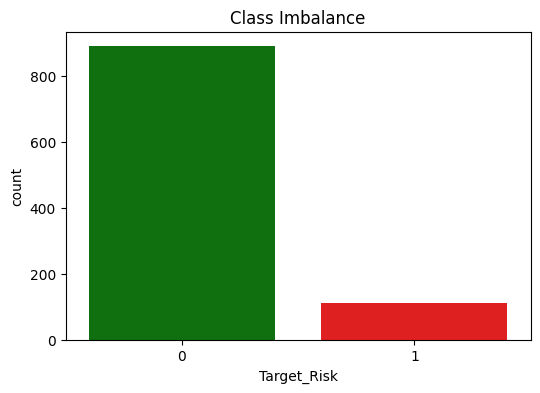

In [47]:
plt.figure(figsize=(6, 4))


sns.countplot(data=df, x='Target_Risk', palette={0: 'green', 1: 'red'}, hue='Target_Risk', legend=False)
plt.title("Class Imbalance")
plt.show()

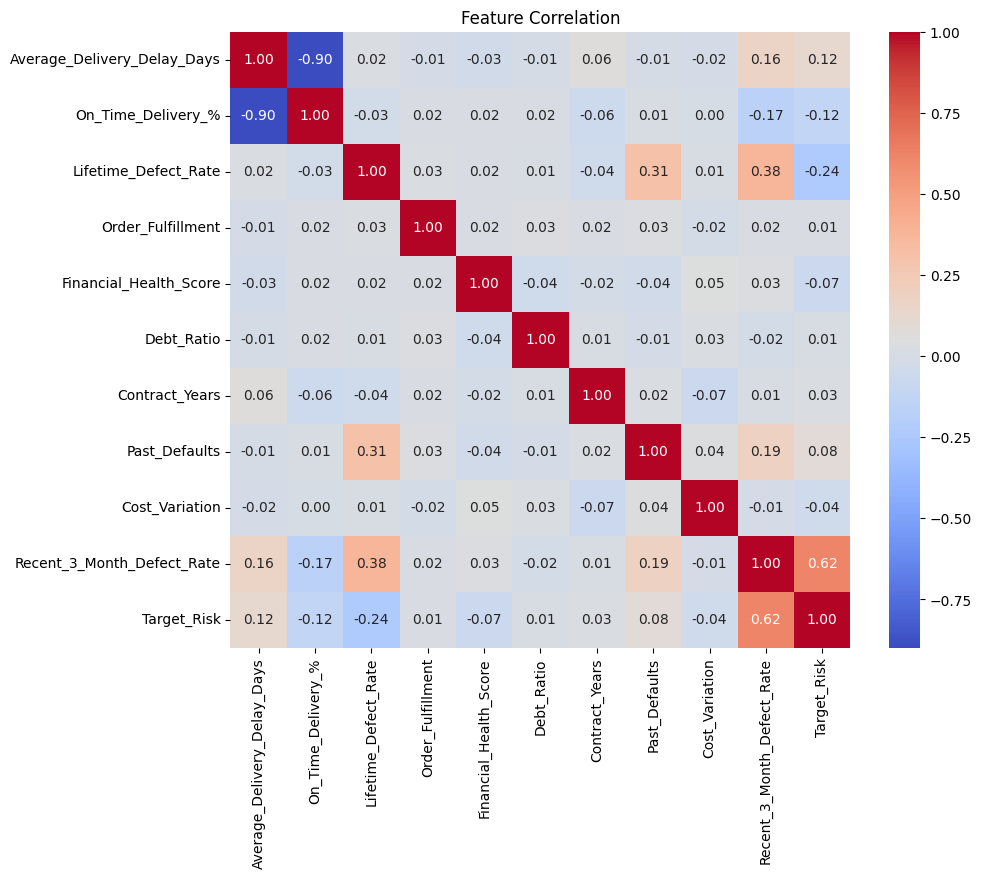

In [48]:
# EDA: Simple Correlation Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['Supplier_ID']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation")
plt.show()

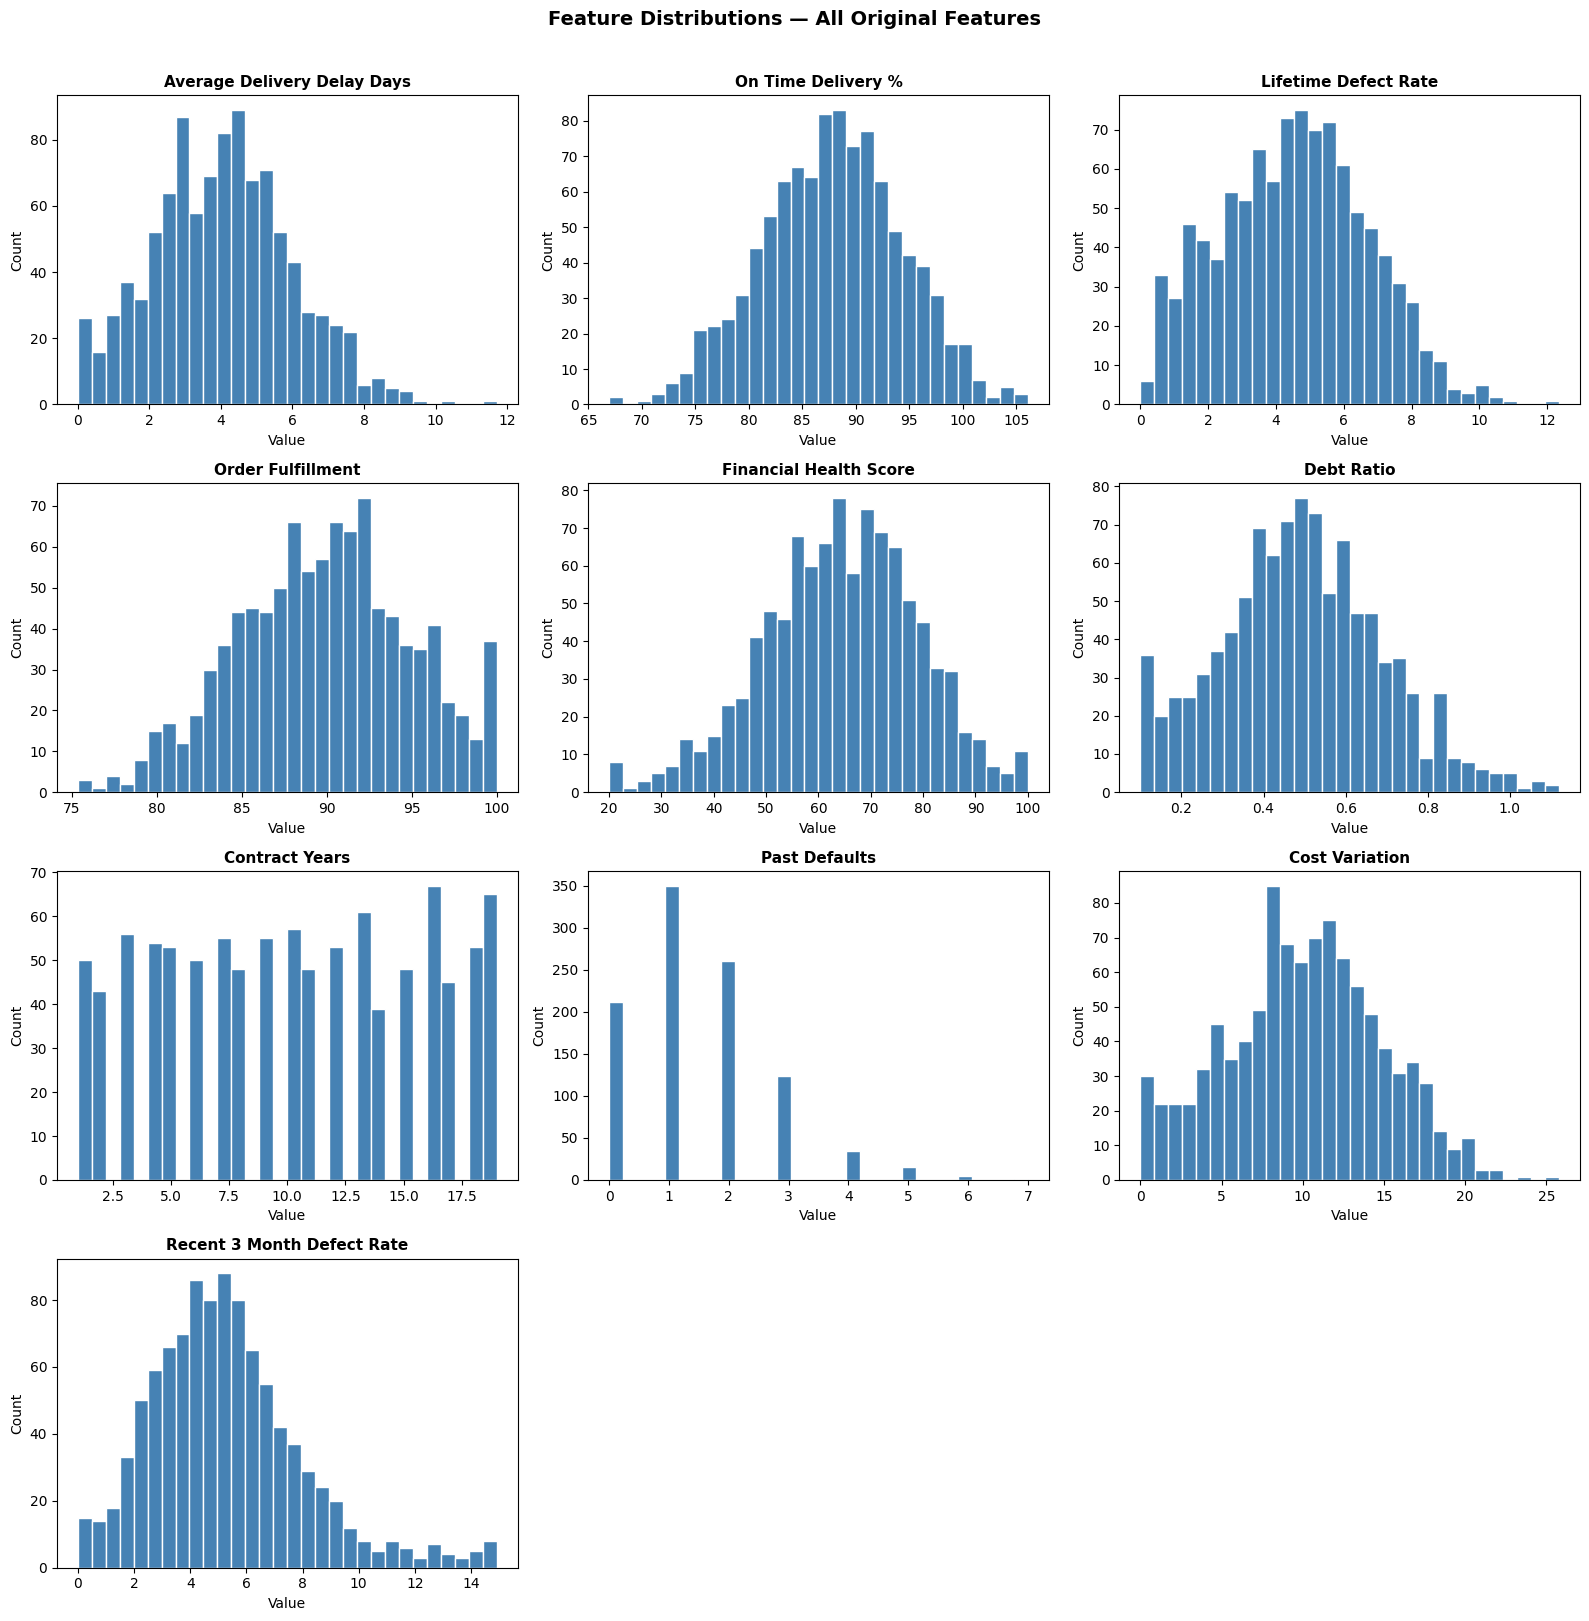

In [49]:
# ── Feature Distribution — Histograms (Auto) ─────────────────────────────────
features_to_plot = [col for col in df.select_dtypes(include='number').columns 
                    if col not in ['Target_Risk', 'Supplier_ID']]

n = len(features_to_plot)
cols = 3
rows = (n + cols - 1) // cols  # auto-calculate rows needed

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions — All Original Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [50]:
# 2. Feature Engineering 

df['Defect_Trajectory'] = df['Recent_3_Month_Defect_Rate'] - df['Lifetime_Defect_Rate']
df['Financial_Stress_Index'] = (100 - df['Financial_Health_Score']) * df['Debt_Ratio']
df['Delivery_Reliability'] = df['On_Time_Delivery_%'] - (df['Average_Delivery_Delay_Days'] * 2)
df['Composite_Risk_Score'] = (
    df['Defect_Trajectory'] * 0.30 +
    df['Financial_Stress_Index'] * 0.25 +
    df['Average_Delivery_Delay_Days'] * 0.20 +
    df['Past_Defaults'] * 5.0 * 0.25
)


engineered_features = [
    'Defect_Trajectory', 
    'Financial_Stress_Index', 
    'Delivery_Reliability', 
    'Composite_Risk_Score'
]


print("Feature Engineering Complete!")
print("Original features  : 11")
print("Engineered features: 4")
print("Total features now : 14\n") 
print("New engineered features:")
for feature in engineered_features:
    print(f"   {feature}")
print("\n")


df[engineered_features].describe().round(3)

Feature Engineering Complete!
Original features  : 11
Engineered features: 4
Total features now : 14

New engineered features:
   Defect_Trajectory
   Financial_Stress_Index
   Delivery_Reliability
   Composite_Risk_Score




,Defect_Trajectory,Financial_Stress_Index,Delivery_Reliability,Composite_Risk_Score
count,1000.000,1000.000,1000.000,1000.000
mean,0.766,17.739,79.697,7.337
std,2.745,10.867,10.158,3.246
min,-1.621,0.000,43.530,0.891
25%,-0.288,9.837,73.350,5.140
50%,0.058,15.900,80.080,6.927
75%,0.421,24.118,86.521,9.168
max,14.346,73.456,105.688,21.823


In [51]:
# 3. Define Features and Target
feature_cols = [c for c in df.columns if c not in ['Supplier_ID', 'Target_Risk']]
X = df[feature_cols].values
y = df['Target_Risk'].values

In [52]:
# 4. Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(" Scaling Applied!")
print("\n BEFORE scaling — first 3 features (raw values):")
print(pd.DataFrame(X[:3, :3], columns=feature_cols[:3]).round(2).to_string())
print("\n AFTER scaling  — same 3 features (Z-scores):")
print(pd.DataFrame(X_scaled[:3, :3], columns=feature_cols[:3]).round(4).to_string())


 Scaling Applied!

 BEFORE scaling — first 3 features (raw values):
   Average_Delivery_Delay_Days  On_Time_Delivery_%  Lifetime_Defect_Rate
0                         4.99               79.92                  3.65
1                         3.72               89.95                  4.21
2                         5.30               84.91                  2.42

 AFTER scaling  — same 3 features (Z-scores):
   Average_Delivery_Delay_Days  On_Time_Delivery_%  Lifetime_Defect_Rate
0                       0.4887             -1.2052               -0.4104
1                      -0.1687              0.3298               -0.1517
2                       0.6450             -0.4418               -0.9795


In [53]:
pca_full = PCA()
pca_full.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [54]:
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Optimal components for 90% variance: {n_90}")

Optimal components for 90% variance: 8


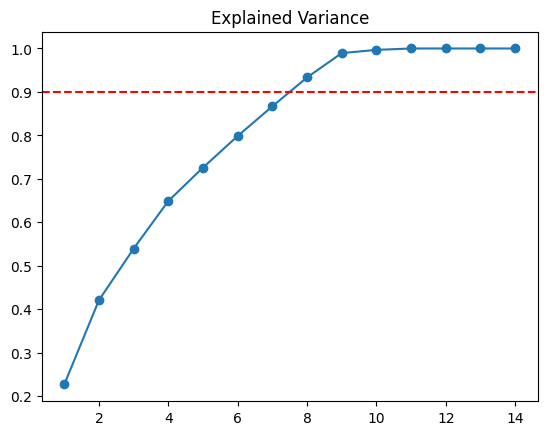

In [55]:
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.title("Explained Variance")
plt.show()

In [56]:
pca = PCA(n_components=n_90)
X_pca = pca.fit_transform(X_scaled)

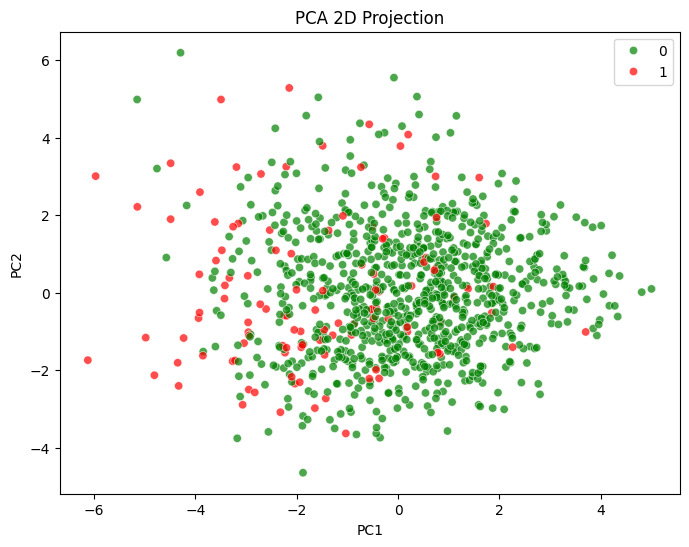

In [57]:
pca_2d = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=y, palette=['green', 'red'], alpha=0.7)
plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [58]:
#splitting into training and testing.
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.20, random_state=42, stratify=y)

print(" Data Split Complete (Stratified)!")
print(f"   Training Set : {X_train.shape[0]:3d} suppliers  "
      f"(Safe: {sum(y_train==0)}, Risky: {sum(y_train==1)})")
print(f"   Testing Set  : {X_test.shape[0]:3d} suppliers  "
      f"(Safe: {sum(y_test==0)}, Risky: {sum(y_test==1)})")

 Data Split Complete (Stratified)!
   Training Set : 800 suppliers  (Safe: 711, Risky: 89)
   Testing Set  : 200 suppliers  (Safe: 178, Risky: 22)


In [59]:
#Applying smote on training data 
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Training data balanced via SMOTE.")
print("SMOTE Applied to Training Set!")
print(f"\n   BEFORE SMOTE:")
print(f"     Safe suppliers  : {sum(y_train==0)}")
print(f"     Risky suppliers : {sum(y_train==1)}")
print(f"     Total           : {len(y_train)}")
print(f"\n   AFTER SMOTE (training only):")
print(f"     Safe suppliers  : {sum(y_train_sm==0)}")
print(f"     Risky suppliers : {sum(y_train_sm==1)}  ← synthetic examples added")
print(f"     Total           : {len(y_train_sm)}")
print(f"\n   Test set remains UNCHANGED: {len(y_test)} real suppliers")

Training data balanced via SMOTE.
SMOTE Applied to Training Set!

   BEFORE SMOTE:
     Safe suppliers  : 711
     Risky suppliers : 89
     Total           : 800

   AFTER SMOTE (training only):
     Safe suppliers  : 711
     Risky suppliers : 711  ← synthetic examples added
     Total           : 1422

   Test set remains UNCHANGED: 200 real suppliers


In [60]:
#Hyperparameter Tuning using GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [61]:
# Logistic Regression
lr_grid = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']}
best_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_grid, cv=cv, scoring='roc_auc').fit(X_train_sm, y_train_sm).best_estimator_

In [62]:
# SVM
svm_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
best_svm = GridSearchCV(SVC(probability=True, random_state=42), svm_grid, cv=cv, scoring='roc_auc').fit(X_train_sm, y_train_sm).best_estimator_

In [63]:
# LDA 
lda_grid = {'solver': ['lsqr'], 'shrinkage': [None, 0.1, 0.5, 'auto']}
best_lda = GridSearchCV(LinearDiscriminantAnalysis(), lda_grid, cv=cv, scoring='roc_auc').fit(X_train_sm, y_train_sm).best_estimator_

In [64]:
#Cross-Validation Score Comparison
models_dict = {'Logistic Regression': best_lr, 'SVM': best_svm, 'LDA': best_lda}
print("\n--- 5-Fold Cross Validation (AUC) ---")
for name, model in models_dict.items():
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='roc_auc')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")


--- 5-Fold Cross Validation (AUC) ---
Logistic Regression: 0.9901 (+/- 0.0009)
SVM: 0.9990 (+/- 0.0011)
LDA: 0.9881 (+/- 0.0010)


In [65]:
# Threshold Tuning (Business Logic)
lr_proba = best_lr.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]

business_thresh = max(0.30, best_thresh - 0.05) # Prioritise recall
print(f"\nOptimised Business Threshold: {business_thresh:.2f}")


Optimised Business Threshold: 0.94


In [66]:
results = []

for name, model in models_dict.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba >= business_thresh).astype(int) if name == 'Logistic Regression' else model.predict(X_test)
    
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        'Model'              : name,
        'ROC-AUC'            : roc_auc_score(y_test, proba),
        'Avg Precision'      : average_precision_score(y_test, proba),
        'Missed Risks (FN)'  : fn,
        'False Alarms (FP)'  : fp
    })

# Final Comparison Table
results_df = pd.DataFrame(results).set_index('Model')
print("\n--- Final Model Comparison ---")
print(results_df)

# Feature Importance: LR retrained on full scaled data (not PCA) for interpretability
lr_interp = LogisticRegression(C=best_lr.C, solver='liblinear', random_state=42).fit(X_scaled, y)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Weight' : lr_interp.coef_[0]
}).sort_values('Weight', key=abs, ascending=False)

print("\n--- Top 5 Features Driving Risk ---")
print(importance_df.head())


--- Final Model Comparison ---
                      ROC-AUC  Avg Precision  Missed Risks (FN)  \
Model                                                             
Logistic Regression  0.986210       0.915362                  6   
SVM                  0.966547       0.690062                  3   
LDA                  0.985955       0.903194                  4   

                     False Alarms (FP)  
Model                                   
Logistic Regression                  2  
SVM                                  9  
LDA                                  7  

--- Top 5 Features Driving Risk ---
                       Feature    Weight
10           Defect_Trajectory  3.307177
9   Recent_3_Month_Defect_Rate  2.639189
4       Financial_Health_Score -1.131941
2         Lifetime_Defect_Rate -0.887724
5                   Debt_Ratio  0.873567


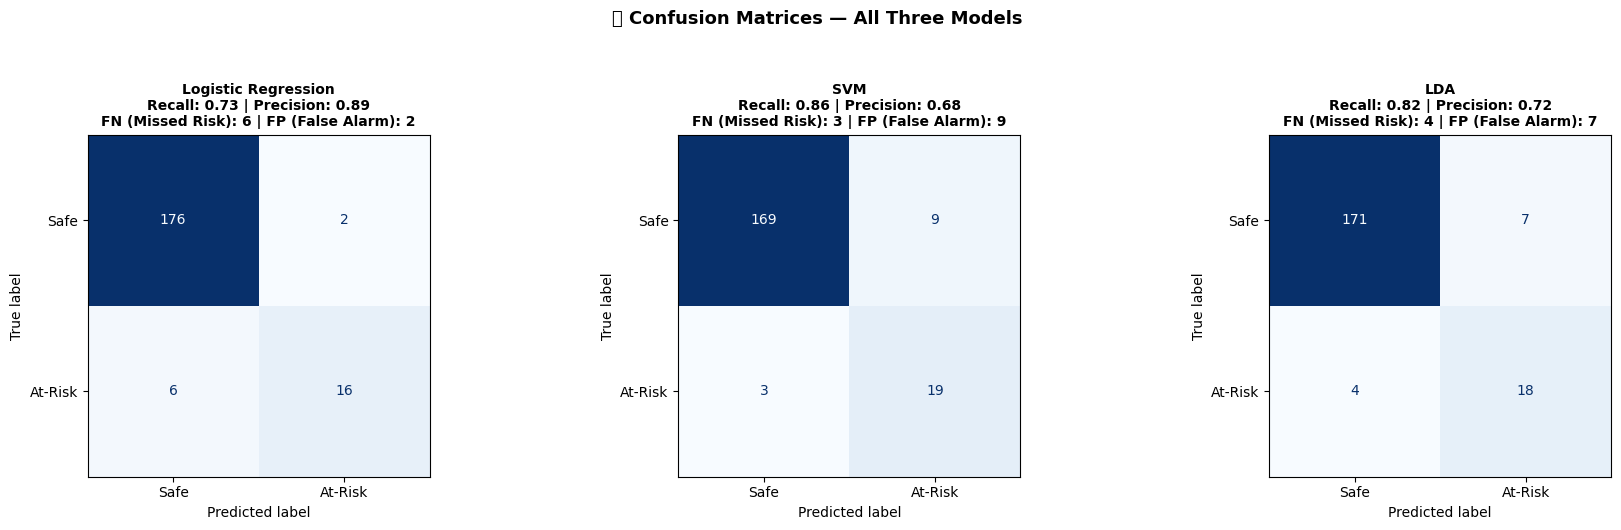

In [67]:
# ── Generate Predictions ──────────────────────────────────────────────────────
predictions = {}
probabilities = {}

for name, model in models_dict.items():
    proba = model.predict_proba(X_test)[:, 1]
    probabilities[name] = proba
    # Use business threshold for Logistic Regression, default for others
    if name == 'Logistic Regression':
        pred = (proba >= business_thresh).astype(int)
    else:
        pred = model.predict(X_test)
    predictions[name] = pred

# ── Plot Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_colors = ['blue', 'red', 'green']
for ax, (name, model), color in zip(axes, models_dict.items(), model_colors):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Safe', 'At-Risk'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    ax.set_title(f'{name}\n'
                 f'Recall: {recall:.2f} | Precision: {precision:.2f}\n'
                 f'FN (Missed Risk): {fn} | FP (False Alarm): {fp}',
                 fontweight='bold', fontsize=10)

plt.suptitle('🔲 Confusion Matrices — All Three Models',
             fontweight='bold', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()


In [68]:
# ── Full Classification Reports ───────────────────────────────────────────────
for name in models_dict:
    print(f"\n{'═'*55}")
    print(f"  {name}")
    print(f"{'═'*55}")
    print(classification_report(y_test, predictions[name],
                                target_names=['Safe', 'At-Risk']))


═══════════════════════════════════════════════════════
  Logistic Regression
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

        Safe       0.97      0.99      0.98       178
     At-Risk       0.89      0.73      0.80        22

    accuracy                           0.96       200
   macro avg       0.93      0.86      0.89       200
weighted avg       0.96      0.96      0.96       200


═══════════════════════════════════════════════════════
  SVM
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

        Safe       0.98      0.95      0.97       178
     At-Risk       0.68      0.86      0.76        22

    accuracy                           0.94       200
   macro avg       0.83      0.91      0.86       200
weighted avg       0.95      0.94      0.94       200


═══════════════════════════════════════════════════════
  LDA
═════════════════════════════

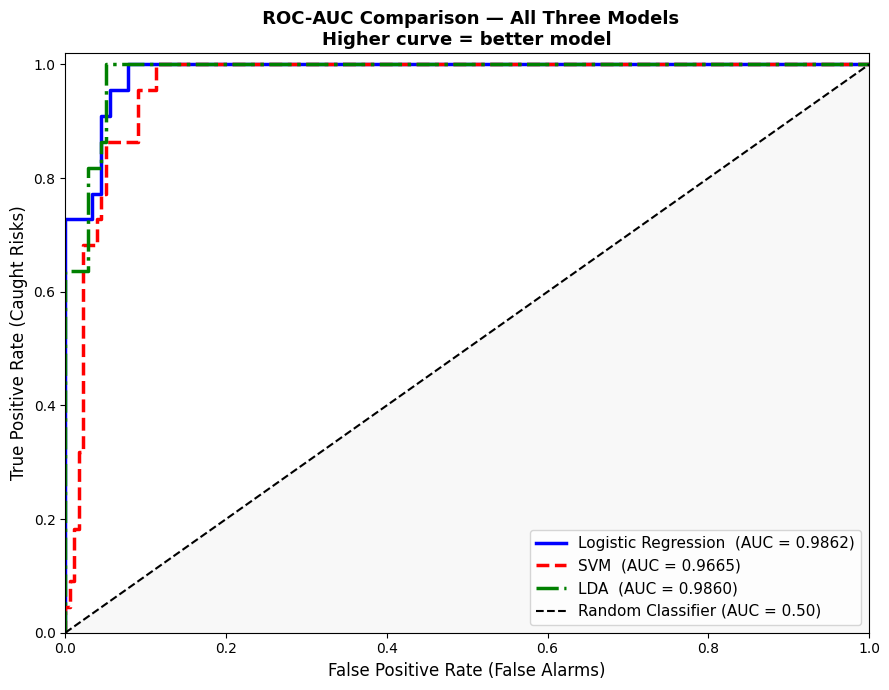


 BEST MODEL BY AUC: Logistic Regression (0.9862)


In [69]:
# ── ROC-AUC Curve — All Three Models on One Chart ────────────────────────────
# The ROC curve plots True Positive Rate vs False Positive Rate at every threshold.
# AUC = Area Under Curve: 0.5 = random, 1.0 = perfect.

fig, ax = plt.subplots(figsize=(9, 7))

model_plot_colors = ['blue', 'red', 'green']
model_linestyles  = ['-', '--', '-.']

auc_scores = {}
for (name, _), color, ls in zip(models_dict.items(), model_plot_colors, model_linestyles):
    proba = probabilities[name]
    auc   = roc_auc_score(y_test, proba)
    auc_scores[name] = auc
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.5,
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate (False Alarms)', fontsize=12)
ax.set_ylabel('True Positive Rate (Caught Risks)', fontsize=12)
ax.set_title(' ROC-AUC Comparison — All Three Models\n'
             'Higher curve = better model',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

# Declare Winner
winner = max(auc_scores, key=auc_scores.get)
print(f"\n BEST MODEL BY AUC: {winner} ({auc_scores[winner]:.4f})")

In [70]:
# ── Predict Risk for a Single Supplier ────────────────────────────────────────
def predict_supplier_risk(raw_data, model=best_lda, threshold=business_thresh):
    """
    Predicts risk for one supplier using the trained LDA model.
    raw_data : dict of all features (original + engineered, matching feature_cols)
    Returns  : dict with 'Decision', 'Probability' (%), and top 3 'Drivers'
    """
    # Step 1 — Build feature vector in exact same column order as training
    X_input = np.array([[raw_data[col] for col in feature_cols]])

    # Step 2 — Scale using the already-fitted scaler (transform only, never re-fit)
    X_input_scaled = scaler.transform(X_input)

    # Step 3 — Compress using the already-fitted PCA (transform only, never re-fit)
    X_input_pca = pca.transform(X_input_scaled)

    # Step 4 — Get risk probability and apply business threshold
    proba    = model.predict_proba(X_input_pca)[0][1] * 100   # convert to percentage
    decision = 'AT-RISK' if (proba / 100) >= threshold else 'SAFE'

    # Step 5 — Compute feature contributions via interpretable LR weights
    weights = lr_interp.coef_[0]
    contributions = {
        col: abs(weights[i] * X_input_scaled[0][i])
        for i, col in enumerate(feature_cols)
    }
    top_3 = dict(sorted(contributions.items(), key=lambda x: x[1], reverse=True)[:3])

    return {'Decision': decision, 'Probability': proba, 'Drivers': top_3}

print("predict_supplier_risk() function defined successfully!")

predict_supplier_risk() function defined successfully!


In [75]:
from IPython.display import display, Markdown


X_all_pca  = pca.transform(scaler.transform(df[feature_cols].values))
all_proba  = best_lda.predict_proba(X_all_pca)[:, 1]
all_pred   = (all_proba >= business_thresh).astype(int)

output_df = pd.DataFrame({
    'Supplier_ID'        : df['Supplier_ID'].values,
    'Actual_Risk'        : df['Target_Risk'].values,
    'Predicted_Risk'     : all_pred,
    'Risk_Probability_%' : (all_proba * 100).round(2)
}).sort_values('Risk_Probability_%', ascending=False).reset_index(drop=True)

at_risk_count = (output_df['Predicted_Risk'] == 1).sum()
print(f"Total Suppliers   : {len(output_df)}")
print(f"At-Risk Suppliers : {at_risk_count}")
print(f"Safe Suppliers    : {len(output_df) - at_risk_count}")


def generate_risk_report(scored_df, original_df, num_rows=10):
    md  = "### Batch Risk Scoring Report\n\n"
    md += "| Rank | Supplier ID | Actual Status | Predicted Status | Risk Prob. | Top Risk Driver 1 | Top Risk Driver 2 | Top Risk Driver 3 |\n"
    md += "| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |\n"

    for rank, (_, row) in enumerate(scored_df.head(num_rows).iterrows(), start=1):
        supp_id  = row['Supplier_ID']
        actual   = "**AT-RISK**" if row['Actual_Risk']    == 1 else "SAFE"
        pred     = "**AT-RISK**" if row['Predicted_Risk'] == 1 else "SAFE"
        prob_val = row['Risk_Probability_%']
        prob_label = f"**{prob_val:.2f}%**" if row['Predicted_Risk'] == 1 else f"{prob_val:.2f}%"

        # Get this supplier's original row for driver calculation
        orig_row = original_df[original_df['Supplier_ID'] == supp_id].iloc[0]
        raw_data = orig_row.drop(['Supplier_ID', 'Target_Risk']).to_dict()
        res      = predict_supplier_risk(raw_data)

        # Clean up driver names
        clean_drivers = []
        for feat, val in list(res['Drivers'].items()):
            clean_feat = (feat.replace('_', ' ')
                             .replace(' Score', '')
                             .replace(' Index', '')
                             .replace(' Rate', ''))
            clean_drivers.append(f"{clean_feat} ({val:.3f})")
        while len(clean_drivers) < 3:
            clean_drivers.append("-")

        md += (f"| {rank} | **{supp_id}** | {actual} | {pred} | {prob_label} "
               f"| {clean_drivers[0]} | {clean_drivers[1]} | {clean_drivers[2]} |\n")

    return md

# ── Step 3: Show top 10 most at-risk suppliers ────────────────────────────────
report_markdown = generate_risk_report(output_df, df, num_rows=10)
display(Markdown(report_markdown))

Total Suppliers   : 1000
At-Risk Suppliers : 67
Safe Suppliers    : 933


### Batch Risk Scoring Report

| Rank | Supplier ID | Actual Status | Predicted Status | Risk Prob. | Top Risk Driver 1 | Top Risk Driver 2 | Top Risk Driver 3 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | **S883** | **AT-RISK** | **AT-RISK** | **100.00%** | Defect Trajectory (14.691) | Recent 3 Month Defect (9.207) | Lifetime Defect (1.121) |
| 2 | **S712** | **AT-RISK** | **AT-RISK** | **100.00%** | Defect Trajectory (14.501) | Recent 3 Month Defect (8.120) | Past Defaults (1.767) |
| 3 | **S69** | **AT-RISK** | **AT-RISK** | **100.00%** | Defect Trajectory (14.846) | Recent 3 Month Defect (9.236) | Financial Health (1.310) |
| 4 | **S780** | **AT-RISK** | **AT-RISK** | **100.00%** | Defect Trajectory (10.125) | Recent 3 Month Defect (5.292) | Financial Health (3.394) |
| 5 | **S616** | **AT-RISK** | **AT-RISK** | **100.00%** | Defect Trajectory (13.679) | Recent 3 Month Defect (8.547) | Past Defaults (1.767) |
| 6 | **S340** | **AT-RISK** | **AT-RISK** | **100.00%** | Defect Trajectory (14.559) | Recent 3 Month Defect (8.544) | Composite Risk (1.364) |
| 7 | **S394** | **AT-RISK** | **AT-RISK** | **100.00%** | Defect Trajectory (14.653) | Recent 3 Month Defect (8.994) | Lifetime Defect (1.197) |
| 8 | **S599** | **AT-RISK** | **AT-RISK** | **100.00%** | Defect Trajectory (16.061) | Recent 3 Month Defect (9.240) | Lifetime Defect (1.572) |
| 9 | **S225** | **AT-RISK** | **AT-RISK** | **99.99%** | Defect Trajectory (12.366) | Recent 3 Month Defect (6.136) | Financial Stress (2.981) |
| 10 | **S65** | **AT-RISK** | **AT-RISK** | **99.99%** | Defect Trajectory (12.935) | Recent 3 Month Defect (7.431) | Lifetime Defect (1.271) |
